### Table of Contents
1. [Imports & Configuration](#1)
2. [Load & Validate Data](#2)
3. [Dataset Augmentation (Small-Data Fix)](#3)
4. [Gaze Dictionary & Alignment](#4)
5. [Local Contradiction Features](#5)
6. [Soft Trigger Labels](#6)
7. [Token Alignment & Dataset](#7)
8. [Model Architecture](#8)
9. [Loss Function + Trigger Sharpness Monitor](#9)
10. [Lambda Sweep — Justify λ](#10)
11. [Full Training (Best λ)](#11)
12. [Full Ablation Study (6 conditions)](#12)
13. [Trigger Evaluation Suite](#13)
14. [Qualitative Analysis](#14)
15. [Visualization Dashboard](#15)

## 1. Imports & Configuration
<a id='1'></a>

In [1]:
!pip install vaderSentiment transformers torch scikit-learn matplotlib seaborn scipy -q

import os, random, unicodedata, re, warnings, json
from pathlib import Path
from copy import deepcopy
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report
)
from scipy.stats import spearmanr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Config ────────────────────────────────────────────────────────────────────
CONFIG = {
    'text_path'                 : '/kaggle/input/datasets/ujjwalgoyalsvnit/filess/text_and_annorations.csv',
    'fix_path'                  : '/kaggle/input/datasets/ujjwalgoyalsvnit/filess/Fixation_sequence.csv',
    'output_dir'                : './outputs',
    'model_name'                : 'bert-base-uncased',
    'max_len'                   : 128,
    'batch_size'                : 16,
    'epochs'                    : 8,
    'lr'                        : 2e-5,
    'dropout'                   : 0.2,
    'lambda_trigger'            : 0.15,   # updated after sweep
    'gaze_z_threshold'          : 0.5,
    'local_window'              : 2,
    'topk'                      : 3,
    'val_size'                  : 0.10,
    'test_size'                 : 0.15,
    'patience'                  : 3,
    'random_seed'               : SEED,
    'aug_factor'                : 2,
    'entropy_collapse_threshold': 0.85,
}

Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VADER  = SentimentIntensityAnalyzer()
SPECIAL_TOKENS = {'[CLS]', '[SEP]', '[PAD]'}

print(f'Device : {DEVICE}')
print(f'Config : {len(CONFIG)} keys')
with open(f'{CONFIG["output_dir"]}/config.json','w') as f:
    json.dump(CONFIG, f, indent=2)
print('Config saved to outputs/config.json')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
Device : cuda
Config : 19 keys
Config saved to outputs/config.json


## 2. Load & Validate Data
<a id='2'></a>

In [2]:
text_df = pd.read_csv(CONFIG['text_path'])
fix_df  = pd.read_csv(CONFIG['fix_path'])

assert {'Text_ID','Text','Sarcasm'}.issubset(text_df.columns), \
    'Missing columns in text file — expected: Text_ID, Text, Sarcasm'
assert {'Text_ID','Word_ID','Word','Fixation_Duration'}.issubset(fix_df.columns), \
    'Missing columns in fixation file — expected: Text_ID, Word_ID, Word, Fixation_Duration'

text_df['Sarcasm'] = text_df['Sarcasm'].map({'Yes':1,'No':0})
text_df = text_df.dropna(subset=['Sarcasm'])
text_df['Sarcasm'] = text_df['Sarcasm'].astype(int)
text_df['Text']    = text_df['Text'].str.strip()

counts = text_df['Sarcasm'].value_counts()
print(f'Total texts    : {len(text_df)}')
print(f'Sarcastic      : {counts[1]}  ({counts[1]/len(text_df):.1%})')
print(f'Non-sarcastic  : {counts[0]}  ({counts[0]/len(text_df):.1%})')
print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1')
print(f'Fixation rows  : {len(fix_df):,} | Participants: {fix_df["Participant_ID"].nunique()}')

Total texts    : 994
Sarcastic      : 350  (35.2%)
Non-sarcastic  : 644  (64.8%)
Imbalance ratio: 1.84:1
Fixation rows  : 161,003 | Participants: 7


## 3. Dataset Augmentation 
<a id='3'></a>

**Problem:** Small dataset (~994 texts, ~350 sarcastic). BERT fine-tuning needs more signal.

**Strategy — Synonym swap (structure-preserving):**
- Replace up to 2 polar words with near-synonyms of the same polarity
- Preserves incongruity structure (sarcasm trigger word still clashes with context)
- Gaze targets inherited from original (word positions unchanged)
- Applied to TRAINING ROWS ONLY — never val/test (prevents data leakage)

In [3]:
SYNONYM_POOL = {
    'great':     ['wonderful','fantastic','brilliant','superb'],
    'wonderful': ['great','brilliant','fantastic','magnificent'],
    'love':      ['adore','enjoy','appreciate','cherish'],
    'terrible':  ['awful','dreadful','horrible','atrocious'],
    'bad':       ['terrible','awful','dreadful','poor'],
    'good':      ['great','fine','excellent','nice'],
    'perfect':   ['ideal','flawless','excellent','superb'],
    'amazing':   ['incredible','remarkable','astonishing','wonderful'],
    'hate':      ['despise','loathe','detest','dislike'],
    'nice':      ['pleasant','lovely','great','fine'],
    'poor':      ['terrible','dreadful','awful','bad'],
    'happy':     ['delighted','thrilled','overjoyed','ecstatic'],
    'sad':       ['miserable','unhappy','depressed','gloomy'],
    'just':      ['only','merely','simply','purely'],
    'sure':      ['certainly','definitely','absolutely','obviously'],
}


def augment_sarcastic_text(text: str, seed: int = 0) -> str:
    """Replace up to 2 words with synonyms. Preserves capitalisation."""
    rng     = np.random.default_rng(seed)
    words   = text.split()
    changed = 0
    for i, word in enumerate(words):
        w_lower = word.lower().rstrip('.,!?')
        if w_lower in SYNONYM_POOL and changed < 2:
            chosen = rng.choice(SYNONYM_POOL[w_lower])
            if word[0].isupper():
                chosen = chosen.capitalize()
            words[i] = chosen
            changed += 1
    return ' '.join(words)


def augment_dataframe(df: pd.DataFrame, aug_factor: int) -> pd.DataFrame:
    """Add aug_factor synthetic sarcastic copies. Aug IDs = orig_id * 10000 + copy_num."""
    sarc_rows = df[df['Sarcasm'] == 1].copy()
    new_rows  = []
    for copy_num in range(1, aug_factor + 1):
        aug = sarc_rows.copy()
        aug['Text']    = aug.apply(
            lambda r: augment_sarcastic_text(r['Text'], seed=int(r['Text_ID']) * copy_num),
            axis=1
        )
        aug['Text_ID'] = aug['Text_ID'] * 10000 + copy_num
        new_rows.append(aug)
    result = pd.concat([df] + new_rows, ignore_index=True)
    print(f'Augmentation: {len(df)} → {len(result)} rows '
          f'(+{len(result)-len(df)} synthetic sarcastic)')
    return result


# Preview
demo = text_df[text_df['Sarcasm']==1]['Text'].iloc[0]
print(f'Original  : {demo}')
for i in range(1, 4):
    print(f'Aug copy {i}: {augment_sarcastic_text(demo, seed=i)}')
print('\nNOTE: Augmentation applied to training rows ONLY after split.')

Original  : I work 40 hours a week to be this poor
Aug copy 1: I work 40 hours a week to be this dreadful
Aug copy 2: I work 40 hours a week to be this bad
Aug copy 3: I work 40 hours a week to be this bad

NOTE: Augmentation applied to training rows ONLY after split.


## 4. Gaze Dictionary & Alignment
<a id='4'></a>

In [4]:
def normalize_word(w: str) -> str:
    w = unicodedata.normalize('NFKD', str(w))
    return re.sub(r'[^\w]', '', w).lower()


def build_gaze_dict(fix_df: pd.DataFrame, text_df: pd.DataFrame) -> dict:
    """
    Build {Text_ID: {words, gaze_raw, gaze_z}} aligned to text word positions.

    Alignment strategy:
      Match gaze-CSV words to text words by unicode-normalised string.
      Handles punctuation stripping and encoding differences.

    Per word:
      gaze_raw : L1-normalised fixation duration (importance weight)
      gaze_z   : within-sentence z-score (used in soft target formula)
    """
    clean = fix_df[~fix_df['Word'].str.startswith('Aspect--', na=False)].copy()
    clean['Word'] = clean['Word'].str.strip()
    agg = (
        clean.groupby(['Text_ID','Word_ID'], sort=False)
             .agg(Word=('Word','first'), Fixation_Duration=('Fixation_Duration','mean'))
             .reset_index()
    )

    gaze_dict       = {}
    alignment_rates = []

    for _, row in text_df.iterrows():
        tid        = row['Text_ID']
        text_words = str(row['Text']).split()
        n          = len(text_words)
        text_norm  = [normalize_word(w) for w in text_words]

        g          = agg[agg['Text_ID'] == tid].sort_values('Word_ID')
        gaze_words = g['Word'].tolist()
        gaze_durs  = g['Fixation_Duration'].values.astype(np.float32)

        aligned_dur = np.zeros(n, dtype=np.float32)
        matched     = 0
        for gw, gd in zip(gaze_words, gaze_durs):
            gn = normalize_word(gw)
            if not gn: continue
            for ti, tn in enumerate(text_norm):
                if tn == gn:
                    aligned_dur[ti] = max(aligned_dur[ti], gd)
                    matched += 1
                    break

        if gaze_words:
            alignment_rates.append(matched / len(gaze_words))

        mu, sigma = aligned_dur.mean(), aligned_dur.std()
        sigma     = sigma if sigma > 0 else 1.0
        gaze_z    = (aligned_dur - mu) / sigma
        norm_raw  = aligned_dur / aligned_dur.sum() \
                    if aligned_dur.sum() > 0 else np.ones(n) / n

        gaze_dict[tid] = {'words': text_words, 'gaze_raw': norm_raw, 'gaze_z': gaze_z}

    print(f'Gaze dict  : {len(gaze_dict)} texts')
    print(f'Alignment  : mean={np.mean(alignment_rates):.1%} '
          f'| >=50% match: {sum(r>=0.5 for r in alignment_rates)}/{len(alignment_rates)}')
    return gaze_dict


gaze_dict = build_gaze_dict(fix_df, text_df)

# Sanity check
ex_id   = text_df[text_df['Sarcasm']==1]['Text_ID'].iloc[2]
ex      = gaze_dict[ex_id]
ex_text = text_df[text_df['Text_ID']==ex_id]['Text'].iloc[0]
print(f'\nExample (ID={ex_id}): "{ex_text}"')
print(f'{"Word":<20} {"gaze_raw":>10} {"gaze_z":>8}')
for w, gr, gz in zip(ex['words'], ex['gaze_raw'], ex['gaze_z']):
    bar = '█' * int(gr * 80)
    print(f'{w:<20} {gr:>10.4f} {gz:>8.2f}  {bar}')

Gaze dict  : 994 texts
Alignment  : mean=94.6% | >=50% match: 994/994

Example (ID=3): "Suburbia: where they tear out the trees and then name streets after them."
Word                   gaze_raw   gaze_z
Suburbia:                0.0702    -0.52  █████
where                    0.0687    -0.63  █████
they                     0.0821     0.40  ██████
tear                     0.0806     0.28  ██████
out                      0.0550    -1.67  ████
the                      0.0733    -0.28  █████
trees                    0.0656    -0.87  █████
and                      0.0797     0.21  ██████
then                     0.0783     0.10  ██████
name                     0.0899     0.99  ███████
streets                  0.0921     1.16  ███████
after                    0.1044     2.10  ████████
them.                    0.0601    -1.29  ████


## 5. Local Contradiction Features
<a id='5'></a>

In [5]:
NEGATORS = {
    'not','never','no','nothing','nowhere','noone','none','cannot',
    "can't","won't","isn't","aren't","wasn't","weren't",
    "don't","doesn't","didn't"
}


def get_vader_negation_aware(word: str, prev_words: list) -> float:
    """VADER compound score, flipped if immediately preceded by a negator."""
    score = VADER.polarity_scores(str(word).strip())['compound']
    if prev_words and prev_words[-1].lower() in NEGATORS:
        score = -score
    return score


def compute_local_contradiction_features(words: list, window: int = 2) -> np.ndarray:
    """
    5-dim LOCAL contradiction feature per word:
      [0] local_gap     : |word_sentiment - mean_neighbor_sentiment|
      [1] sign_flip     : 1 if word & neighbors have opposite polarity signs
      [2] |word_sent|   : absolute VADER score of word
      [3] |neigh_sent|  : absolute mean VADER score of neighbors
      [4] is_polar      : 1 if |word_sent| > 0.05

    Basis: Riloff et al. 2013 — positive verbs in negative situations
    are the canonical sarcasm trigger pattern.
    """
    n          = len(words)
    word_sents = np.array(
        [get_vader_negation_aware(w, words[:i]) for i, w in enumerate(words)],
        dtype=np.float32
    )
    features = np.zeros((n, 5), dtype=np.float32)

    for i in range(n):
        nb_idx    = [j for j in range(max(0, i-window), min(n, i+window+1)) if j != i]
        ws        = word_sents[i]
        if nb_idx:
            nb_sents  = word_sents[nb_idx]
            mean_nb   = float(np.mean(nb_sents))
            local_gap = abs(ws - mean_nb)
            sign_flip = float(abs(ws)>0.05 and abs(mean_nb)>0.05 and ws*mean_nb<0)
        else:
            mean_nb = local_gap = sign_flip = 0.0
        features[i] = [local_gap, sign_flip, abs(ws), abs(mean_nb), float(abs(ws)>0.05)]

    return features


# Demo
demo_texts = [
    'Great job breaking everything again.',
    'Nice perfume. Must you marinate in it?',
    'I work 40 hours a week to be this poor.',
    'Yeah because that worked out SO well last time.',
    'Oh wonderful another Monday morning.',
]
print('=== LOCAL CONTRADICTION FEATURE DEMO ===')
for text in demo_texts:
    words = text.split()
    feats = compute_local_contradiction_features(words, CONFIG['local_window'])
    print(f'\n"{text}"')
    print(f'  {"Word":<20} {"local_gap":>10} {"sign_flip":>10} {"|vader|":>8}')
    for w, f in zip(words, feats):
        flag = '  ◄ TRIGGER CANDIDATE' if f[0]>0.2 or f[1]>0 else ''
        if f[2] > 0.05 or f[0] > 0.1:
            print(f'  {w:<20} {f[0]:>10.3f} {f[1]:>10.0f} {f[2]:>8.3f}{flag}')

=== LOCAL CONTRADICTION FEATURE DEMO ===

"Great job breaking everything again."
  Word                  local_gap  sign_flip  |vader|
  Great                     0.625          0    0.625  ◄ TRIGGER CANDIDATE
  job                       0.208          0    0.000  ◄ TRIGGER CANDIDATE
  breaking                  0.156          0    0.000

"Nice perfume. Must you marinate in it?"
  Word                  local_gap  sign_flip  |vader|
  Nice                      0.421          0    0.421  ◄ TRIGGER CANDIDATE
  perfume.                  0.140          0    0.000
  Must                      0.105          0    0.000

"I work 40 hours a week to be this poor."
  Word                  local_gap  sign_flip  |vader|
  be                        0.119          0    0.000
  this                      0.159          0    0.000
  poor.                     0.477          0    0.477  ◄ TRIGGER CANDIDATE

"Yeah because that worked out SO well last time."
  Word                  local_gap  sign_flip  |vade

## 6. Soft Trigger Labels
<a id='6'></a>

In [6]:
def build_soft_trigger_targets(words, gaze_z, contra_feats, z_threshold=0.5):
    """
    Soft trigger probability per word:
      score[i] = max(0, gaze_z[i]) * (1 + local_gap[i])
    Then L1-normalise → probability distribution summing to 1.
    Returns all-zeros if no gaze signal (excluded from KL loss via has_target mask).
    """
    local_gap     = contra_feats[:, 0]
    gaze_positive = np.maximum(0.0, gaze_z)
    raw           = gaze_positive * (1.0 + local_gap)
    total         = raw.sum()
    if total > 1e-8:
        return (raw / total).astype(np.float32)
    return np.zeros(len(words), dtype=np.float32)


def build_dataset_rows(text_df, gaze_dict, config):
    """
    Build one row dict per sentence.
    Augmented rows (Text_ID > 9999) look up gaze from original (id // 10000).
    """
    rows, skipped = [], 0
    for _, row in text_df.iterrows():
        tid      = row['Text_ID']
        orig_tid = tid // 10000 if tid > 9999 else tid
        if orig_tid not in gaze_dict:
            skipped += 1
            continue
        g     = gaze_dict[orig_tid]
        words = str(row['Text']).split()
        n     = len(words)
        gz    = g['gaze_z'][:n]   if len(g['gaze_z'])>=n   else np.pad(g['gaze_z'],   (0, n-len(g['gaze_z'])))
        gr    = g['gaze_raw'][:n] if len(g['gaze_raw'])>=n else np.pad(g['gaze_raw'], (0, n-len(g['gaze_raw'])))
        sarc  = int(row['Sarcasm'])
        contra = compute_local_contradiction_features(words, config['local_window'])
        trig   = build_soft_trigger_targets(words, gz, contra, config['gaze_z_threshold']) \
                 if sarc == 1 else np.zeros(n, dtype=np.float32)
        rows.append({
            'text'            : row['Text'],
            'label'           : sarc,
            'gaze_words'      : words,
            'gaze_scores'     : gr,
            'gaze_z'          : gz,
            'trigger_targets' : trig,
            'contra_features' : contra,
        })
    sarc_n = sum(r['label'] for r in rows)
    print(f'Rows: {len(rows)} (sarc={sarc_n}, non={len(rows)-sarc_n}) | skipped={skipped}')
    return rows


all_rows_orig = build_dataset_rows(text_df, gaze_dict, CONFIG)
print(f'Original rows: {len(all_rows_orig)}')

Rows: 994 (sarc=350, non=644) | skipped=0
Original rows: 994


## 7. Token Alignment, Dataset & DataLoaders
<a id='7'></a>

In [7]:
TOKENIZER = AutoTokenizer.from_pretrained(CONFIG['model_name'])


def is_valid_token(tok: str) -> bool:
    """Exclude special and subword-continuation tokens."""
    return tok not in SPECIAL_TOKENS and tok != '[PAD]' and not tok.startswith('##')


def align_to_tokens(text, word_values, tokenizer, max_len=128):
    """
    Align word-level arrays to BERT subword tokens via word_ids().
    Handles 1-D and 2-D (n_words, feat_dim) inputs.
    """
    enc      = tokenizer(text, truncation=True, padding='max_length',
                         max_length=max_len, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)
    tokens   = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    word_arr = np.array(word_values)
    is_2d    = word_arr.ndim == 2
    feat_dim = word_arr.shape[1] if is_2d else 1
    aligned  = np.zeros((max_len, feat_dim) if is_2d else (max_len,), dtype=np.float32)
    for ti, wid in enumerate(word_ids):
        if wid is not None and wid < len(word_arr):
            aligned[ti] = word_arr[wid]
    return tokens, aligned


class SarcasmDataset(Dataset):
    def __init__(self, rows, tokenizer, max_len):
        self.rows = rows; self.tok = tokenizer; self.max_len = max_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r   = self.rows[idx]
        enc = self.tok(r['text'], truncation=True, padding='max_length',
                       max_length=self.max_len, return_tensors='pt')
        _, ta = align_to_tokens(r['text'], r['trigger_targets'], self.tok, self.max_len)
        _, ca = align_to_tokens(r['text'], r['contra_features'], self.tok, self.max_len)
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(r['label'], dtype=torch.long),
            'trigger_targets': torch.tensor(ta, dtype=torch.float),
            'contra_features': torch.tensor(ca, dtype=torch.float),
        }


# ── Three-way stratified split ────────────────────────────────────────────────
labels_all = [r['label'] for r in all_rows_orig]
train_val, test_rows = train_test_split(
    all_rows_orig, test_size=CONFIG['test_size'],
    stratify=labels_all, random_state=SEED
)
tv_labels = [r['label'] for r in train_val]
val_frac   = CONFIG['val_size'] / (1 - CONFIG['test_size'])
train_rows_orig, val_rows = train_test_split(
    train_val, test_size=val_frac, stratify=tv_labels, random_state=SEED
)

# ── Augment TRAINING only ─────────────────────────────────────────────────────
train_texts  = {r['text'] for r in train_rows_orig}
train_tids   = set(text_df[text_df['Text'].isin(train_texts)]['Text_ID'].tolist())
aug_text_df  = augment_dataframe(
    text_df[text_df['Text_ID'].isin(train_tids)].copy(), CONFIG['aug_factor']
)
train_rows_aug = build_dataset_rows(aug_text_df, gaze_dict, CONFIG)

print(f'\nTrain (augmented): {len(train_rows_aug)} | Val: {len(val_rows)} | Test: {len(test_rows)}')
print('Test set is held-out — never seen during training or lambda tuning.')

# ── Weighted sampler for class balance ────────────────────────────────────────
train_labels  = [r['label'] for r in train_rows_aug]
class_counts  = np.bincount(train_labels)
class_weights = 1.0 / class_counts
samp_weights  = torch.tensor([class_weights[l] for l in train_labels], dtype=torch.float)
sampler       = WeightedRandomSampler(samp_weights, len(samp_weights), replacement=True)
CE_WEIGHTS    = torch.tensor(class_weights, dtype=torch.float)

train_ds = SarcasmDataset(train_rows_aug, TOKENIZER, CONFIG['max_len'])
val_ds   = SarcasmDataset(val_rows,       TOKENIZER, CONFIG['max_len'])
test_ds  = SarcasmDataset(test_rows,      TOKENIZER, CONFIG['max_len'])

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'])
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'])
print(f'Train batches: {len(train_loader)}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Augmentation: 744 → 1268 rows (+524 synthetic sarcastic)
Rows: 1268 (sarc=786, non=482) | skipped=0

Train (augmented): 1268 | Val: 100 | Test: 150
Test set is held-out — never seen during training or lambda tuning.
Train batches: 80


## 8. Model Architecture
<a id='8'></a>

In [8]:
CONTRA_DIM = 5

class SarcasmTriggerModel(nn.Module):
    def __init__(self, model_name, dropout=0.2,
                 use_gaze=True, use_contradiction=True):
        super().__init__()
        # FIX: force eager attention so output_attentions=True works
        self.bert = AutoModel.from_pretrained(
            model_name,
            attn_implementation='eager'   # ← THIS IS THE FIX
        )
        H = self.bert.config.hidden_size
        self.use_gaze          = use_gaze
        self.use_contradiction = use_contradiction

        self.sarc_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(H, 2)
        )
        trig_in = H + (CONTRA_DIM if use_contradiction else 0)
        self.trigger_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(trig_in, 128), nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask, contra_features=None):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                           output_attentions=True)
        hidden = out.last_hidden_state
        self._attentions = out.attentions   # now works because eager mode is on

        sarc_logits = self.sarc_head(out.pooler_output)

        if self.use_contradiction and contra_features is not None:
            trig_in = torch.cat([hidden, contra_features], dim=-1)
        else:
            trig_in = hidden

        trig_logits = self.trigger_head(trig_in).squeeze(-1)
        return sarc_logits, trig_logits

    def cls_attention_scores(self):
        """CLS-to-token attention from last layer, head-averaged → (B, seq)."""
        # FIX: guard against None in case attentions weren't stored yet
        if self._attentions is None:
            return None
        return self._attentions[-1][:, :, 0, :].mean(1)


def freeze_bert(model):
    for p in model.bert.parameters(): p.requires_grad = False

def unfreeze_bert(model):
    for p in model.bert.parameters(): p.requires_grad = True


print('Model defined.')
print('  Sarcasm head : BERT[CLS] → Dropout → Linear(768, 2)')
print('  Trigger head : BERT[H_i] + ContraFeat → Dropout → Linear → GELU → Linear(1)')
print('  Attentions   : stored per forward pass (used in BERT-attention baseline)')

Model defined.
  Sarcasm head : BERT[CLS] → Dropout → Linear(768, 2)
  Trigger head : BERT[H_i] + ContraFeat → Dropout → Linear → GELU → Linear(1)
  Attentions   : stored per forward pass (used in BERT-attention baseline)


## 9. Loss Function + Trigger Sharpness Monitor
<a id='9'></a>

**Loss:** `L = CE(sarcasm, class_weighted) + λ × KL(softmax(trigger), soft_gaze_target)`

**Sharpness monitor:** Entropy of predicted trigger distributions per epoch.
- Max possible entropy for seq_len=128: log(128) ≈ 4.85 nats
- If mean entropy > 85% of max → trigger head is flat → **collapse warning**

In [9]:
def compute_loss(sarc_log, trig_log, labels, trig_targets,
                 attn_mask, lambda_trig, use_gaze, ce_weights_t):
    """
    KL computed only on sarcastic rows with non-zero gaze targets.
    PAD tokens masked before softmax.
    """
    sarc_loss = F.cross_entropy(sarc_log, labels, weight=ce_weights_t)
    if not use_gaze:
        zero = torch.tensor(0.0, device=sarc_log.device)
        return sarc_loss, sarc_loss, zero

    sarc_mask  = (labels == 1)
    has_target = trig_targets.sum(dim=1) > 1e-6
    active     = sarc_mask & has_target
    if active.sum() == 0:
        zero = torch.tensor(0.0, device=sarc_log.device)
        return sarc_loss, sarc_loss, zero

    tlog_a  = trig_log[active]
    ttarg_a = trig_targets[active]
    mask_a  = attn_mask[active]
    pad_m   = (mask_a == 0)

    log_q   = F.log_softmax(tlog_a.masked_fill(pad_m, -1e9), dim=-1)
    p       = ttarg_a.masked_fill(pad_m, 0.0)
    p       = p / p.sum(dim=-1, keepdim=True).clamp(min=1e-8)

    trig_loss  = F.kl_div(log_q, p, reduction='batchmean')
    total_loss = sarc_loss + lambda_trig * trig_loss
    return total_loss, sarc_loss, trig_loss


def compute_trigger_entropy(model, loader, device, max_len):
    """
    Mean entropy of trigger prob distributions over sarcastic val rows.
    Returns: mean_entropy, max_entropy, collapse_flag
    """
    model.eval()
    entropies   = []
    max_entropy = np.log(max_len)

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            cf   = batch['contra_features'].to(device)
            labs = batch['label']
            _, tlog = model(ids, mask, cf)
            sarc_idx = (labs == 1).nonzero(as_tuple=True)[0]
            if len(sarc_idx) == 0: continue
            tlog_s = tlog[sarc_idx]
            mask_s = mask[sarc_idx]
            probs  = F.softmax(tlog_s.masked_fill(mask_s==0, -1e9), dim=-1).clamp(min=1e-8)
            ent    = -(probs * probs.log()).sum(dim=-1)
            entropies.extend(ent.cpu().tolist())

    if not entropies:
        return max_entropy, max_entropy, True

    mean_ent = float(np.mean(entropies))
    collapse = mean_ent > CONFIG['entropy_collapse_threshold'] * max_entropy
    return mean_ent, max_entropy, collapse


print('Loss function and sharpness monitor defined.')
print(f'Max entropy (seq_len={CONFIG["max_len"]}): {np.log(CONFIG["max_len"]):.3f} nats')
print(f'Collapse threshold: > {CONFIG["entropy_collapse_threshold"]*100:.0f}% of max entropy')

Loss function and sharpness monitor defined.
Max entropy (seq_len=128): 4.852 nats
Collapse threshold: > 85% of max entropy


In [10]:
LAMBDA_VALUES = [0.05, 0.10, 0.15, 0.20, 0.30]
SWEEP_EPOCHS  = 3


def quick_pak(model, rows, tok, device, k):
    """Fast P@k computation for sweep."""
    scores = []
    for row in rows:
        if row['label'] != 1: continue
        enc = tok(row['text'], truncation=True, padding='max_length',
                  max_length=CONFIG['max_len'], return_tensors='pt')
        ids = enc['input_ids'].to(device); msk = enc['attention_mask'].to(device)
        _, ca = align_to_tokens(row['text'], row['contra_features'], tok, CONFIG['max_len'])
        cf = torch.tensor(ca).unsqueeze(0).to(device)
        with torch.no_grad():
            _, tl = model(ids, msk, cf)
        probs = F.softmax(tl.masked_fill(msk==0, -1e9), dim=-1)[0].cpu().numpy()
        toks  = tok.convert_ids_to_tokens(ids[0])
        _, ga = align_to_tokens(row['text'], row['trigger_targets'], tok, CONFIG['max_len'])
        valid = [i for i, t in enumerate(toks) if is_valid_token(t)]
        if len(valid) < k: continue
        pk = set(sorted(valid, key=lambda i: probs[i], reverse=True)[:k])
        gk = set(sorted(valid, key=lambda i: ga[i],    reverse=True)[:k])
        scores.append(len(pk & gk) / k)
    return float(np.mean(scores)) if scores else 0.0


sweep_results = {}
print(f'Lambda sweep: {LAMBDA_VALUES} | {SWEEP_EPOCHS} epochs each')
print(f'{"lambda":>8} {"val_F1":>8} {"val_KL":>9} {"P@k":>7} {"Entropy":>9} {"Status"}')
print('─' * 58)

for lam in LAMBDA_VALUES:
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    m = SarcasmTriggerModel(CONFIG['model_name'], CONFIG['dropout'],
                             use_gaze=True, use_contradiction=True).to(DEVICE)
    opt = torch.optim.AdamW([
        {'params': m.bert.parameters(),         'lr': CONFIG['lr']},
        {'params': m.sarc_head.parameters(),    'lr': CONFIG['lr']*5},
        {'params': m.trigger_head.parameters(), 'lr': CONFIG['lr']*5},
    ], weight_decay=0.01)
    ce_w = CE_WEIGHTS.to(DEVICE)

    for ep in range(1, SWEEP_EPOCHS+1):
        if ep == 1: freeze_bert(m)
        elif ep == 2: unfreeze_bert(m)
        m.train()
        for batch in train_loader:
            ids  = batch['input_ids'].to(DEVICE); mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE);      trigs = batch['trigger_targets'].to(DEVICE)
            cf   = batch['contra_features'].to(DEVICE)
            opt.zero_grad()
            sl, tl = m(ids, mask, cf)
            loss, _, _ = compute_loss(sl, tl, labs, trigs, mask, lam, True, ce_w)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()

    m.eval(); vkl_list, vpred, vlab = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch['input_ids'].to(DEVICE); mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE);      trigs = batch['trigger_targets'].to(DEVICE)
            cf   = batch['contra_features'].to(DEVICE)
            sl, tl = m(ids, mask, cf)
            _, _, tl2 = compute_loss(sl, tl, labs, trigs, mask, lam, True, ce_w)
            vkl_list.append(tl2.item() if hasattr(tl2, 'item') else float(tl2))
            vpred.extend(sl.argmax(-1).cpu().tolist())
            vlab.extend(labs.cpu().tolist())

    vf1  = f1_score(vlab, vpred, average='macro', zero_division=0)
    vkl  = float(np.mean(vkl_list))
    pak  = quick_pak(m, val_rows, TOKENIZER, DEVICE, CONFIG['topk'])
    ent, _, collapse = compute_trigger_entropy(m, val_loader, DEVICE, CONFIG['max_len'])
    status = '⚠ COLLAPSE' if collapse else 'OK'

    sweep_results[lam] = {'val_f1': vf1, 'val_kl': vkl, 'pak': pak,
                           'entropy': ent, 'collapse': collapse}
    print(f'{lam:>8.2f} {vf1:>8.4f} {vkl:>9.4f} {pak:>7.4f} {ent:>9.4f} {status}')

best_lam = max(sweep_results,
               key=lambda l: 0.7*sweep_results[l]['val_f1'] + 0.3*sweep_results[l]['pak'])
CONFIG['lambda_trigger'] = best_lam
print(f'\nBest λ = {best_lam}  '
      f'(val_F1={sweep_results[best_lam]["val_f1"]:.4f}, '
      f'P@{CONFIG["topk"]}={sweep_results[best_lam]["pak"]:.4f})')
print(f'CONFIG["lambda_trigger"] updated to {best_lam}')

Lambda sweep: [0.05, 0.1, 0.15, 0.2, 0.3] | 3 epochs each
  lambda   val_F1    val_KL     P@k   Entropy Status
──────────────────────────────────────────────────────────


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    0.05   0.9566    1.1912  0.1619    2.9663 OK


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    0.20   0.9341    1.2294  0.1714    2.8882 OK


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    0.30   0.9226    1.2603  0.1905    2.8688 OK

Best λ = 0.05  (val_F1=0.9566, P@3=0.1619)
CONFIG["lambda_trigger"] updated to 0.05


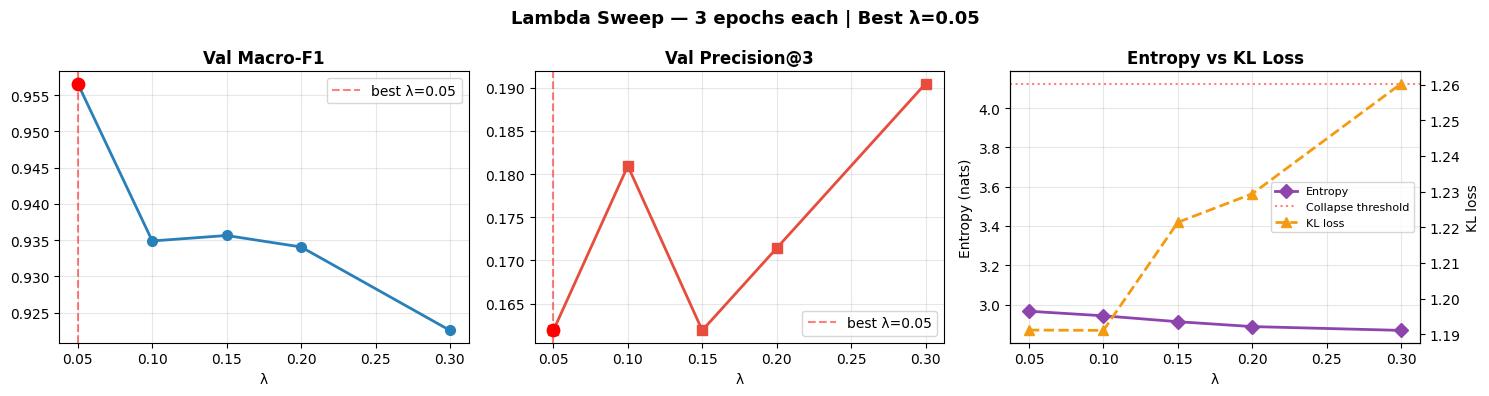

Lambda sweep plot saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Lambda Sweep — {SWEEP_EPOCHS} epochs each | Best λ={best_lam}',
             fontsize=13, fontweight='bold')

lams = list(sweep_results.keys())
f1s  = [sweep_results[l]['val_f1']  for l in lams]
kls  = [sweep_results[l]['val_kl']  for l in lams]
paks = [sweep_results[l]['pak']     for l in lams]
ents = [sweep_results[l]['entropy'] for l in lams]

def mark_best(ax, xs, ys, bx):
    bi = xs.index(bx)
    ax.axvline(bx, color='red', ls='--', alpha=0.5, label=f'best λ={bx}')
    ax.scatter([bx], [ys[bi]], color='red', zorder=5, s=80)

axes[0].plot(lams, f1s, '-o', color='#2980B9', lw=2, ms=7)
mark_best(axes[0], lams, f1s, best_lam)
axes[0].set_title('Val Macro-F1', fontweight='bold')
axes[0].set_xlabel('λ'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(lams, paks, '-s', color='#E74C3C', lw=2, ms=7)
mark_best(axes[1], lams, paks, best_lam)
axes[1].set_title(f'Val Precision@{CONFIG["topk"]}', fontweight='bold')
axes[1].set_xlabel('λ'); axes[1].legend(); axes[1].grid(alpha=0.3)

ax_e = axes[2]; ax_k = ax_e.twinx()
ax_e.plot(lams, ents, '-D', color='#8E44AD', lw=2, ms=7, label='Entropy')
ax_k.plot(lams, kls,  '--^', color='#F39C12', lw=2, ms=7, label='KL loss')
ax_e.axhline(CONFIG['entropy_collapse_threshold'] * np.log(CONFIG['max_len']),
             color='red', ls=':', alpha=0.5, label='Collapse threshold')
ax_e.set_title('Entropy vs KL Loss', fontweight='bold'); ax_e.set_xlabel('λ')
ax_e.set_ylabel('Entropy (nats)'); ax_k.set_ylabel('KL loss')
lines1, lbls1 = ax_e.get_legend_handles_labels()
lines2, lbls2 = ax_k.get_legend_handles_labels()
ax_e.legend(lines1 + lines2, lbls1 + lbls2, fontsize=8)
ax_e.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/lambda_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lambda sweep plot saved.')

## 11. Full Training (Best λ)
<a id='11'></a>

In [12]:
def run_training(variant_name, use_gaze, use_contradiction, lambda_trig=None):
    """
    Full training with:
      - BERT frozen epoch 1, unfrozen from epoch 2
      - Linear warmup + decay LR schedule
      - Layer-wise LR: BERT < task heads
      - Patience-based early stopping on combined F1+P@k score
      - Sharpness check each epoch
      - Saves best checkpoint, reloads at end
    """
    if lambda_trig is None:
        lambda_trig = CONFIG['lambda_trigger']
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    model = SarcasmTriggerModel(
        CONFIG['model_name'], CONFIG['dropout'],
        use_gaze=use_gaze, use_contradiction=use_contradiction
    ).to(DEVICE)

    ce_w      = CE_WEIGHTS.to(DEVICE)
    optimizer = torch.optim.AdamW([
        {'params': model.bert.parameters(),         'lr': CONFIG['lr']},
        {'params': model.sarc_head.parameters(),    'lr': CONFIG['lr']*5},
        {'params': model.trigger_head.parameters(), 'lr': CONFIG['lr']*5},
    ], weight_decay=0.01)

    total_steps = len(train_loader) * CONFIG['epochs']
    warmup      = int(0.1 * total_steps)
    scheduler   = get_linear_schedule_with_warmup(optimizer, warmup, total_steps)

    history = defaultdict(list)
    best_score, patience_cnt = -1.0, 0
    best_preds, best_labels  = None, None
    ckpt = f'{CONFIG["output_dir"]}/best_{variant_name}.pt'

    print(f'\n══ {variant_name} (λ={lambda_trig}) ══')
    print(f'{"Ep":<4} {"TrLoss":<10} {"SarcLoss":<10} {"KL":<8} '
          f'{"VaLoss":<10} {"VaF1":<8} {"P@k":<8} {"Entropy":<10} Status')
    print('─' * 80)

    for ep in range(1, CONFIG['epochs']+1):
        if ep == 1: freeze_bert(model)
        elif ep == 2: unfreeze_bert(model)

        model.train()
        tl_acc = sl_acc = kl_acc = nb = 0
        for batch in train_loader:
            ids  = batch['input_ids'].to(DEVICE);  mask  = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE);       trigs = batch['trigger_targets'].to(DEVICE)
            cf   = batch['contra_features'].to(DEVICE)
            optimizer.zero_grad()
            sl, tl = model(ids, mask, cf)
            loss, sl2, kl2 = compute_loss(sl, tl, labs, trigs, mask, lambda_trig, use_gaze, ce_w)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            tl_acc += loss.item(); sl_acc += sl2.item()
            kl_acc += kl2.item() if hasattr(kl2, 'item') else float(kl2)
            nb += 1

        model.eval()
        vl_acc = 0; vp, vl = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch['input_ids'].to(DEVICE);  mask  = batch['attention_mask'].to(DEVICE)
                labs = batch['label'].to(DEVICE);       trigs = batch['trigger_targets'].to(DEVICE)
                cf   = batch['contra_features'].to(DEVICE)
                sl, tl = model(ids, mask, cf)
                l, _, _ = compute_loss(sl, tl, labs, trigs, mask, lambda_trig, use_gaze, ce_w)
                vl_acc += l.item()
                vp.extend(sl.argmax(-1).cpu().tolist())
                vl.extend(labs.cpu().tolist())

        vf1 = f1_score(vl, vp, average='macro', zero_division=0)
        pak = quick_pak(model, val_rows, TOKENIZER, DEVICE, CONFIG['topk'])
        ent, _, collapse = compute_trigger_entropy(model, val_loader, DEVICE, CONFIG['max_len'])

        history['train_loss'].append(tl_acc/nb)
        history['sarc_loss'].append(sl_acc/nb)
        history['kl_loss'].append(kl_acc/nb)
        history['val_loss'].append(vl_acc/len(val_loader))
        history['val_f1'].append(vf1)
        history['pak'].append(pak)
        history['entropy'].append(ent)

        combined = 0.7*vf1 + 0.3*pak
        if combined > best_score:
            best_score = combined; patience_cnt = 0
            best_preds, best_labels = vp, vl
            torch.save(model.state_dict(), ckpt)
            status = '◄ saved'
        else:
            patience_cnt += 1
            status = f'pat {patience_cnt}/{CONFIG["patience"]}'

        collapse_flag = '  ⚠COLLAPSE' if collapse else ''
        print(f'{ep:<4} {tl_acc/nb:<10.4f} {sl_acc/nb:<10.4f} {kl_acc/nb:<8.4f} '
              f'{vl_acc/len(val_loader):<10.4f} {vf1:<8.4f} {pak:<8.4f} '
              f'{ent:<10.4f} {status}{collapse_flag}')

        if patience_cnt >= CONFIG['patience']:
            print(f'  Early stop at epoch {ep}')
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    print(f'Best: F1={max(history["val_f1"]):.4f} | P@{CONFIG["topk"]}={max(history["pak"]):.4f}')
    return model, best_preds, best_labels, dict(history)


print('Training function defined.')
print('Section 12 runs all 6 ablation conditions.')

Training function defined.
Section 12 runs all 6 ablation conditions.


## 12. Full Ablation Study — 6 Conditions
<a id='12'></a>

| Condition | CE | KL | Contradiction | λ | Purpose |
|---|---|---|---|---|---|
| A | ✓ | ✗ | ✗ | — | Pure BERT baseline |
| B | ✓ | ✓ | ✗ | 0.05 | Gaze, weak λ |
| C | ✓ | ✓ | ✗ | best | Gaze, best λ |
| D | ✓ | ✓ | ✓ | 0.05 | Full model, weak λ |
| E | ✓ | ✓ | ✓ | best | **Full model, best λ (ours)** |
| F | ✓ | ✓ | ✓ | 0.30 | Full model, strong λ |

In [13]:
ABLATION_RUNS = [
    ('A_CE_only',         False, False, None),
    ('B_Gaze_weakLam',    True,  False, 0.05),
    ('C_Gaze_bestLam',    True,  False, None),
    ('D_Full_weakLam',    True,  True,  0.05),
    ('E_Full_bestLam',    True,  True,  None),
    ('F_Full_strongLam',  True,  True,  0.30),
]

trained_models = {}
all_histories  = {}

for name, use_gaze, use_contra, lam in ABLATION_RUNS:
    m, bp, bl, hist = run_training(name, use_gaze, use_contra, lambda_trig=lam)
    trained_models[name] = (m, bp, bl)
    all_histories[name]  = hist

model_A = trained_models['A_CE_only'][0]
model_E = trained_models['E_Full_bestLam'][0]
print('\nAll 6 ablation models trained.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



══ A_CE_only (λ=0.05) ══
Ep   TrLoss     SarcLoss   KL       VaLoss     VaF1     P@k      Entropy    Status
────────────────────────────────────────────────────────────────────────────────
1    0.7356     0.7356     0.0000   0.5521     0.3902   0.2190   3.1031     ◄ saved
2    0.2855     0.2855     0.0000   0.1917     0.9236   0.1810   3.1035     ◄ saved
3    0.0836     0.0836     0.0000   0.6686     0.8859   0.1905   3.1034     pat 1/3
4    0.0333     0.0333     0.0000   0.3053     0.9467   0.2190   3.1033     ◄ saved
5    0.0209     0.0209     0.0000   0.3709     0.9363   0.2095   3.1033     pat 1/3
6    0.0039     0.0039     0.0000   0.3764     0.9467   0.2286   3.1033     ◄ saved
7    0.0005     0.0005     0.0000   0.3596     0.9467   0.2286   3.1033     pat 1/3
8    0.0004     0.0004     0.0000   0.3727     0.9467   0.2286   3.1033     pat 2/3
Best: F1=0.9467 | P@3=0.2286


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



══ E_Full_bestLam (λ=0.05) ══
Ep   TrLoss     SarcLoss   KL       VaLoss     VaF1     P@k      Entropy    Status
────────────────────────────────────────────────────────────────────────────────
1    0.7669     0.7159     1.0186   0.6156     0.3902   0.1524   3.0588     ◄ saved
2    0.3219     0.2720     0.9981   0.3267     0.8494   0.1714   3.0313     ◄ saved
3    0.1108     0.0646     0.9256   0.3074     0.9356   0.2190   2.9721     ◄ saved
4    0.0806     0.0373     0.8664   0.4254     0.9245   0.1810   2.9270     pat 1/3
5    0.0447     0.0066     0.7623   0.4456     0.9245   0.1810   2.8845     pat 2/3
6    0.0343     0.0009     0.6679   0.5000     0.9142   0.2286   2.8456     pat 3/3
  Early stop at epoch 6
Best: F1=0.9356 | P@3=0.2286


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



══ F_Full_strongLam (λ=0.3) ══
Ep   TrLoss     SarcLoss   KL       VaLoss     VaF1     P@k      Entropy    Status
────────────────────────────────────────────────────────────────────────────────
1    1.0215     0.7159     1.0186   0.9085     0.3902   0.1524   3.0588     ◄ saved
2    0.5749     0.2810     0.9797   0.6385     0.8467   0.1524   3.0185     ◄ saved
3    0.3163     0.0593     0.8566   0.5914     0.9253   0.2000   2.9001     ◄ saved
4    0.2326     0.0366     0.6533   0.8278     0.9159   0.2000   2.7897     pat 1/3
5    0.1483     0.0137     0.4488   0.7003     0.9142   0.2190   2.7275     pat 2/3
6    0.1083     0.0029     0.3512   0.7595     0.9151   0.2286   2.6770     ◄ saved
7    0.0953     0.0024     0.3098   0.7179     0.9349   0.2190   2.6687     ◄ saved
8    0.0860     0.0016     0.2816   0.7209     0.9349   0.2190   2.6587     pat 1/3
Best: F1=0.9349 | P@3=0.2286

All 6 ablation models trained.


## 13. Trigger Evaluation Suite
<a id='13'></a>

| Metric | Measures | Answers |
|---|---|---|
| Precision@k | Overlap of top-k predicted vs gaze top-k | Are the right tokens found? |
| Spearman ρ | Rank correlation: pred probs vs gaze scores | Is the ranking correct? |
| Token IoU@k | Exact match intersection-over-union | How precise is the hit? |
| Entropy | Distribution entropy (lower = sharper) | Is the model confident? |
| Contra hit rate | Fraction of top-k that are locally contradictory | Did it learn incongruity? |

**BERT-Attention Baseline:** CLS-to-token attention as trigger scores — no trigger head training.
If our trained head beats this, KL supervision adds real value beyond raw BERT attention.

In [ ]:
def get_trigger_probs(model, row, tokenizer, device, max_len=128):
    """Softmax trigger probabilities from trained trigger head."""
    model.eval()
    enc  = tokenizer(row['text'], truncation=True, padding='max_length',
                     max_length=max_len, return_tensors='pt')
    ids  = enc['input_ids'].to(device); mask = enc['attention_mask'].to(device)
    _, ca = align_to_tokens(row['text'], row['contra_features'], tokenizer, max_len)
    cf   = torch.tensor(ca).unsqueeze(0).to(device)
    with torch.no_grad():
        _, tlog = model(ids, mask, cf)
    probs = F.softmax(tlog.masked_fill(mask==0, -1e9), dim=-1)[0].cpu().numpy()
    toks  = tokenizer.convert_ids_to_tokens(ids[0])
    return toks, probs


def get_attention_baseline_probs(model, row, tokenizer, device, max_len=128):
    model.eval()
    enc  = tokenizer(row['text'], truncation=True, padding='max_length',
                     max_length=max_len, return_tensors='pt')
    ids  = enc['input_ids'].to(device); mask = enc['attention_mask'].to(device)
    _, ca = align_to_tokens(row['text'], row['contra_features'], tokenizer, max_len)
    cf   = torch.tensor(ca).unsqueeze(0).to(device)
    with torch.no_grad():
        model(ids, mask, cf)

    attn_scores = model.cls_attention_scores()
    # FIX: fallback to uniform if attentions unavailable
    if attn_scores is None:
        seq_len = ids.shape[1]
        attn = np.ones(seq_len, dtype=np.float32) / seq_len
    else:
        attn = attn_scores[0].cpu().numpy()

    attn  = np.where(mask[0].cpu().numpy()==0, 0, attn)
    probs = attn / (attn.sum() + 1e-8)
    toks  = tokenizer.convert_ids_to_tokens(ids[0])
    return toks, probs


def evaluate_trigger_full(model, rows, tokenizer, device, k=3, use_attn_baseline=False):
    pak_scores, spear_scores, overlap_scores, ent_scores, hit_scores = [], [], [], [], []

    for row in rows:
        if row['label'] != 1: continue
        if use_attn_baseline:
            toks, pred_probs = get_attention_baseline_probs(model, row, tokenizer, device)
        else:
            toks, pred_probs = get_trigger_probs(model, row, tokenizer, device)

        _, gaze_aligned = align_to_tokens(row['text'], row['trigger_targets'],
                                           tokenizer, CONFIG['max_len'])
        _, ca_aligned   = align_to_tokens(row['text'], row['contra_features'],
                                           tokenizer, CONFIG['max_len'])
        valid = [i for i, t in enumerate(toks) if is_valid_token(t)]
        if len(valid) < k: continue

        pred_topk = sorted(valid, key=lambda i: pred_probs[i],    reverse=True)[:k]
        gaze_topk = sorted(valid, key=lambda i: gaze_aligned[i],  reverse=True)[:k]

        # Precision@k
        pak_scores.append(len(set(pred_topk) & set(gaze_topk)) / k)

        # Spearman ρ
        pred_v = pred_probs[valid]; gaze_v = gaze_aligned[valid]
        if np.std(gaze_v) > 0:
            rho, _ = spearmanr(pred_v, gaze_v)
            if not np.isnan(rho): spear_scores.append(rho)

        # Token IoU@k
        inter = len(set(pred_topk) & set(gaze_topk))
        union = len(set(pred_topk) | set(gaze_topk))
        overlap_scores.append(inter/union if union > 0 else 0)

        # Entropy
        p = pred_probs[valid]; p = p/p.sum(); p = np.clip(p, 1e-8, None)
        ent_scores.append(-(p * np.log(p)).sum())

        # Contradiction hit rate
        hits = sum(1 for i in pred_topk if ca_aligned[i, 1] > 0)
        hit_scores.append(hits / k)

    def sm(lst): return float(np.mean(lst)) if lst else 0.0
    return {
        'precision_at_k' : sm(pak_scores),
        'spearman_rho'   : sm(spear_scores),
        'token_overlap'  : sm(overlap_scores),
        'entropy'        : sm(ent_scores),
        'contra_hit_rate': sm(hit_scores),
    }


# ── Evaluate all models on TEST SET ──────────────────────────────────────────
print('='*72)
print('TRIGGER EVALUATION SUITE — TEST SET')
print('='*72)
print(f'{"Model":<26} {"P@k":>7} {"Spearρ":>8} {"IoU@k":>7} {"Entropy":>9} {"ContraHit":>10}')
print('─'*72)

test_trigger_results = {}

attn_res = evaluate_trigger_full(model_A, test_rows, TOKENIZER, DEVICE,
                                  CONFIG['topk'], use_attn_baseline=True)
test_trigger_results['Attn Baseline (no train)'] = attn_res
r = attn_res
print(f'{"Attn Baseline (no train)":<26} {r["precision_at_k"]:>7.4f} {r["spearman_rho"]:>8.4f} '
      f'{r["token_overlap"]:>7.4f} {r["entropy"]:>9.4f} {r["contra_hit_rate"]:>10.4f}')

for abl_name, (m, _, _) in trained_models.items():
    res = evaluate_trigger_full(m, test_rows, TOKENIZER, DEVICE, CONFIG['topk'])
    test_trigger_results[abl_name] = res
    r   = res
    print(f'{abl_name:<26} {r["precision_at_k"]:>7.4f} {r["spearman_rho"]:>8.4f} '
          f'{r["token_overlap"]:>7.4f} {r["entropy"]:>9.4f} {r["contra_hit_rate"]:>10.4f}')

k = CONFIG['topk']
print(f'\n  P@{k}      = Precision@{k}: top-k overlap with gaze ground truth')
print(f'  Spearρ    = Spearman rank correlation (pred probs vs gaze scores)')1
print(f'  IoU@{k}    = token intersection-over-union @ top-{k}')
print(f'  Entropy   = mean entropy of trigger distribution (lower = sharper)')
print(f'  ContraHit = fraction of top-{k} predictions with local sign-flip')

TRIGGER EVALUATION SUITE — TEST SET
Model                          P@k   Spearρ   IoU@k   Entropy  ContraHit
────────────────────────────────────────────────────────────────────────
Attn Baseline (no train)    0.1069  -0.0638  0.0679    2.5447     0.0000
A_CE_only                   0.2013   0.0545  0.1302    2.8993     0.0000
B_Gaze_weakLam              0.2138   0.0590  0.1396    2.8231     0.0063
C_Gaze_bestLam              0.2138   0.0590  0.1396    2.8231     0.0063
D_Full_weakLam              0.2516   0.0873  0.1623    2.8406     0.0314
E_Full_bestLam              0.2516   0.0873  0.1623    2.8406     0.0314
F_Full_strongLam            0.1824   0.0989  0.1113    2.6144     0.0314

  P@3      = Precision@3: top-k overlap with gaze ground truth
  Spearρ    = Spearman rank correlation (pred probs vs gaze scores)
  IoU@3    = token intersection-over-union @ top-3
  Entropy   = mean entropy of trigger distribution (lower = sharper)
  ContraHit = fraction of top-3 predictions with local 

## 14. Qualitative Analysis
<a id='14'></a>

Rich per-sentence display: trigger prob bar, top-k tokens, VADER scores, local contrast flags.

In [15]:
def rich_case_study(text, model, tokenizer, device, k=3,
                     gaze_targets=None, truth_label=None, max_len=128):
    words    = text.split()
    contra_f = compute_local_contradiction_features(words, CONFIG['local_window'])

    model.eval()
    enc  = tokenizer(text, truncation=True, padding='max_length',
                     max_length=max_len, return_tensors='pt')
    ids  = enc['input_ids'].to(device); mask = enc['attention_mask'].to(device)
    _, ca = align_to_tokens(text, contra_f, tokenizer, max_len)
    cf   = torch.tensor(ca).unsqueeze(0).to(device)

    with torch.no_grad():
        slog, tlog = model(ids, mask, cf)

    sarc_pred = slog.argmax(-1).item()
    sarc_conf = F.softmax(slog, dim=-1)[0, sarc_pred].item()
    probs     = F.softmax(tlog.masked_fill(mask==0, -1e9), dim=-1)[0].cpu().numpy()
    toks      = tokenizer.convert_ids_to_tokens(ids[0])

    valid    = [i for i, t in enumerate(toks) if is_valid_token(t)]
    topk_ids = set(sorted(valid, key=lambda i: probs[i], reverse=True)[:k])

    gaze_topk = set()
    if gaze_targets is not None:
        _, ga = align_to_tokens(text, gaze_targets, tokenizer, max_len)
        gaze_topk = set(sorted(valid, key=lambda i: ga[i], reverse=True)[:k])

    _, ca_al = align_to_tokens(text, contra_f, tokenizer, max_len)

    sarc_str  = 'SARCASTIC' if sarc_pred == 1 else 'NOT SARCASTIC'
    correct   = (truth_label is None) or (sarc_pred == truth_label)
    truth_str = f' | truth={"sarcastic" if truth_label==1 else "non-sarcastic"}' \
                if truth_label is not None else ''
    sym       = '✓' if correct else '✗'

    print('─'*72)
    print(f'Text      : "{text}"')
    print(f'Prediction: {sarc_str} ({sarc_conf:.0%} confidence)  {sym}{truth_str}')

    if sarc_pred == 0:
        print('  [Trigger display suppressed — not sarcastic]')
        print()
        return

    print(f'\n  {"Token":<18} {"Prob":>6} {"VADER":>7}  Bar (×50)                Flags')
    print('  ' + '─'*72)

    for i, tok in [(i, t) for i, t in enumerate(toks) if is_valid_token(t)]:
        prob    = probs[i]
        bar_len = int(prob * 150)
        bar     = ('█' * min(24, bar_len)).ljust(24, '░')
        flags   = []
        if i in topk_ids:  flags.append('◄ TOP-K')
        if i in gaze_topk: flags.append('👁 GAZE-GT')
        if ca_al[i, 1] > 0: flags.append('⚡ CONTRAST')
        vader_s = VADER.polarity_scores(tok)['compound']
        marker  = '▶ ' if i in topk_ids else '  '
        print(f'{marker}{tok:<18} {prob:>6.4f} {vader_s:>7.3f}  {bar}  {" ".join(flags)}')

    hit = len(topk_ids & gaze_topk)
    print(f'\n  P@{k} for this sentence: {hit}/{k} = {hit/k:.2f}')
    print()


print('='*72)
print('QUALITATIVE CASE STUDIES — Model E (Full Model, Best λ)')
print('='*72)
sarc_test = [r for r in test_rows if r['label']==1][:8]
for r in sarc_test:
    rich_case_study(r['text'], model_E, TOKENIZER, DEVICE,
                    k=CONFIG['topk'], gaze_targets=r['trigger_targets'], truth_label=1)

print('='*72)
print('CUSTOM INFERENCE EXAMPLES')
print('='*72)
custom = [
    'Yeah great, just what I needed today.',
    'Oh wonderful, another Monday morning meeting.',
    'Nice perfume. Must you marinate in it?',
    'I work 40 hours a week to be this poor.',
    'I love this camera, it takes amazing photos.',
]
for text in custom:
    rich_case_study(text, model_E, TOKENIZER, DEVICE, k=CONFIG['topk'])

QUALITATIVE CASE STUDIES — Model E (Full Model, Best λ)
────────────────────────────────────────────────────────────────────────
Text      : "I just love having my eyes water when I sneeze."
Prediction: SARCASTIC (100% confidence)  ✓ | truth=sarcastic

  Token                Prob   VADER  Bar (×50)                Flags
  ────────────────────────────────────────────────────────────────────────
  i                  0.0526   0.000  ███████░░░░░░░░░░░░░░░░░  
  just               0.0579   0.000  ████████░░░░░░░░░░░░░░░░  👁 GAZE-GT
  love               0.0763   0.637  ███████████░░░░░░░░░░░░░  
  having             0.0791   0.000  ███████████░░░░░░░░░░░░░  
  my                 0.0765   0.000  ███████████░░░░░░░░░░░░░  
▶ eyes               0.1197   0.000  █████████████████░░░░░░░  ◄ TOP-K
  water              0.0797   0.000  ███████████░░░░░░░░░░░░░  👁 GAZE-GT
▶ when               0.0956   0.000  ██████████████░░░░░░░░░░  ◄ TOP-K
  i                  0.0844   0.000  ████████████░░░░░░░░░░░

## 15. Visualization Dashboard
<a id='15'></a>

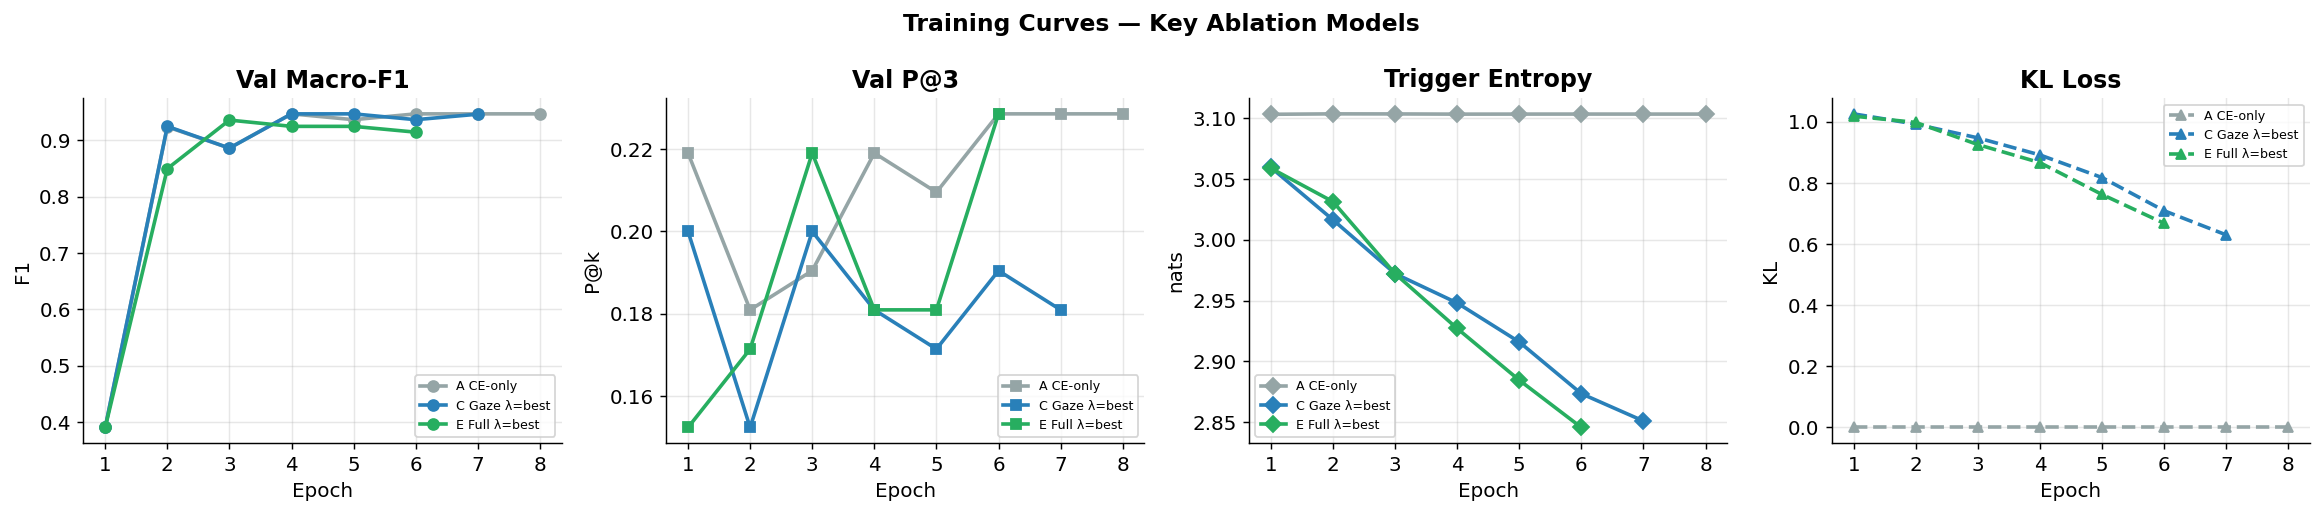

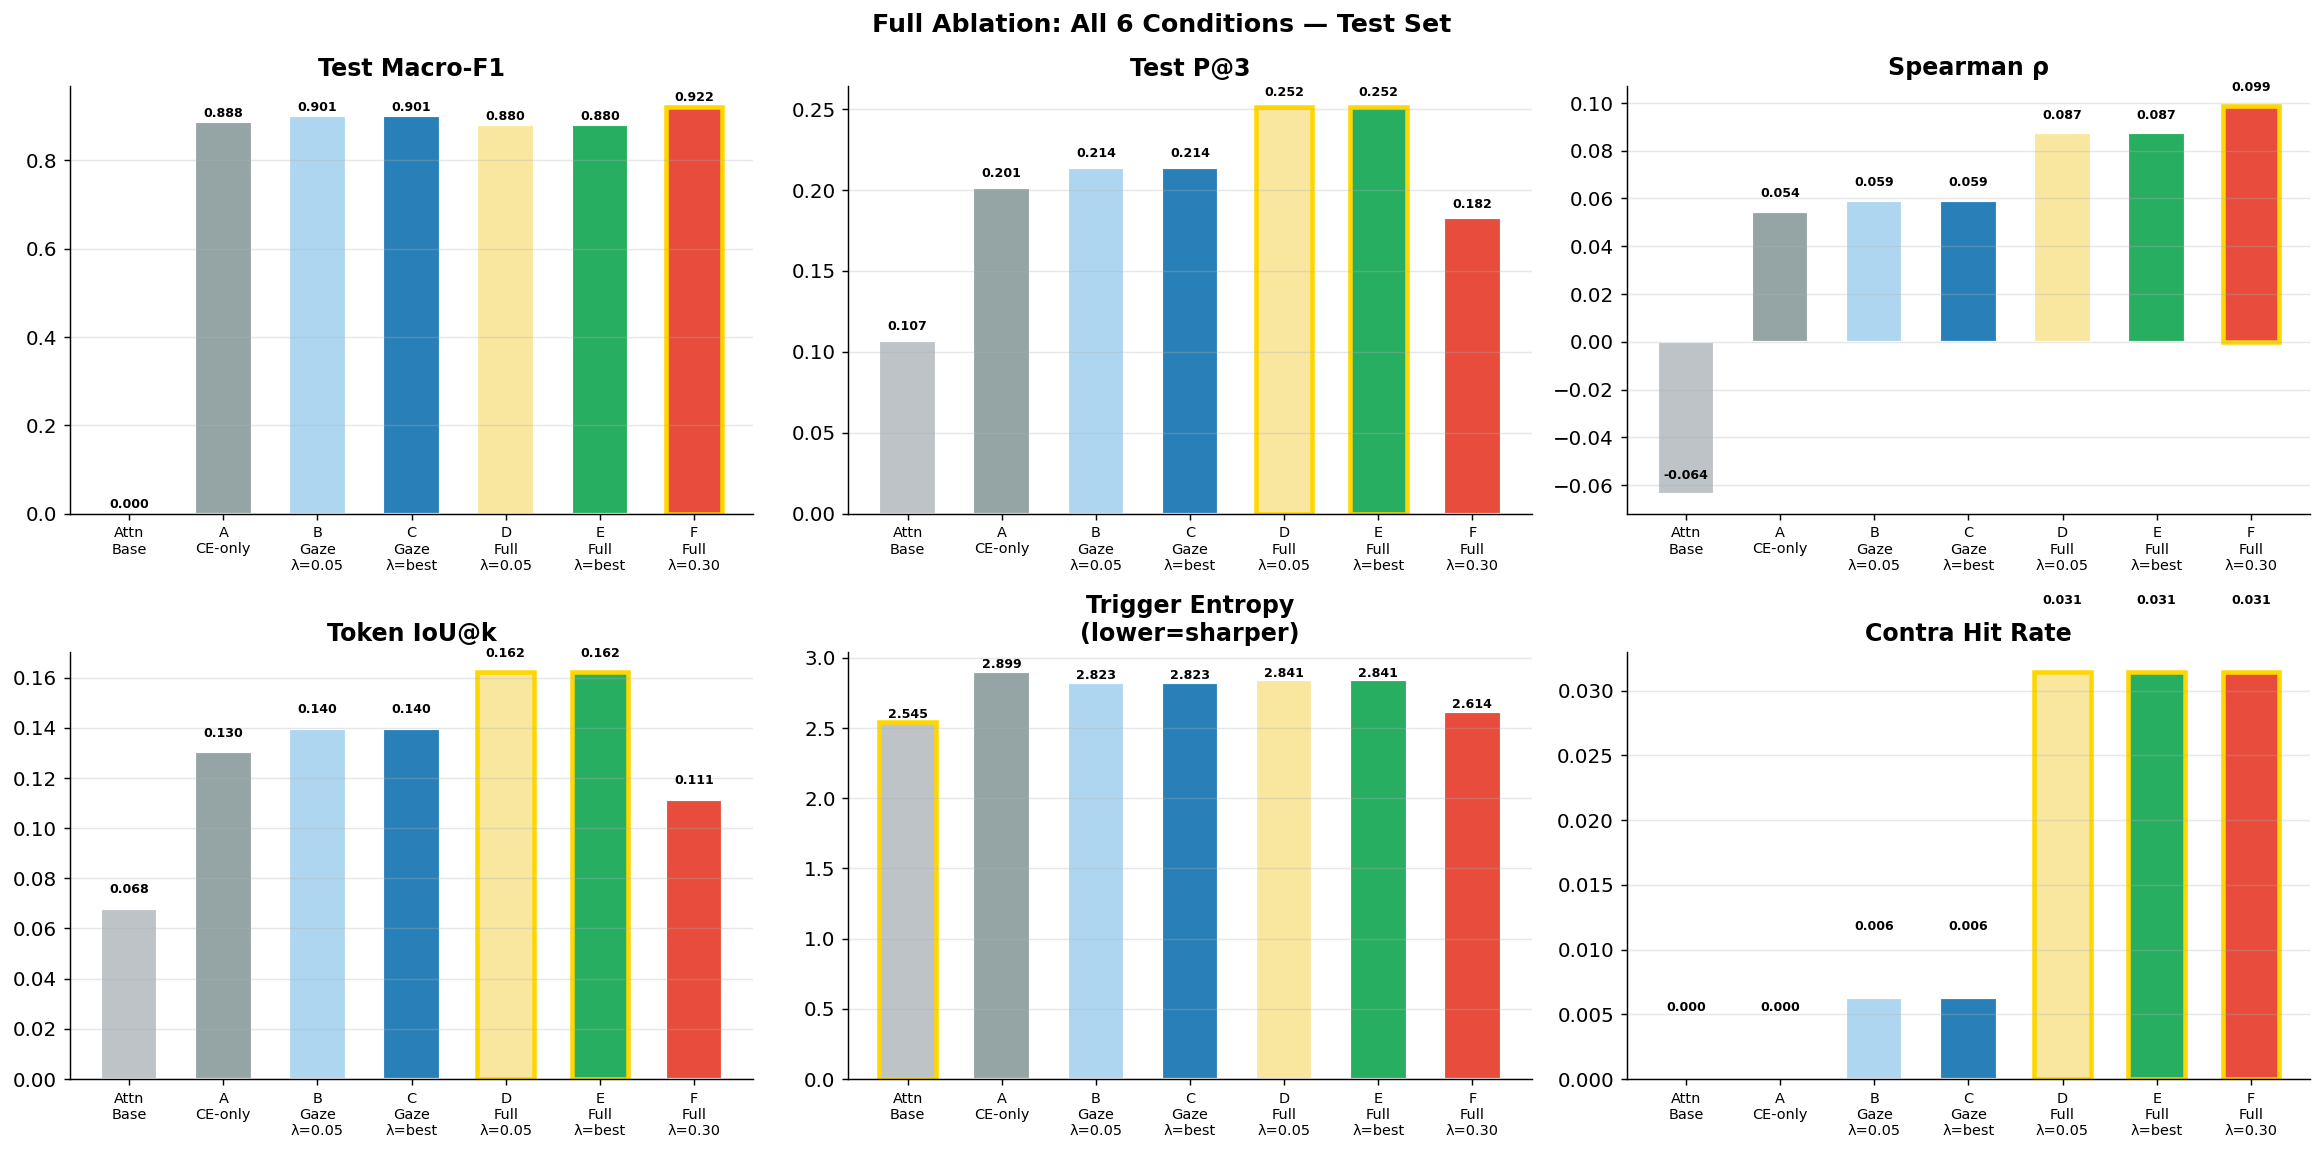

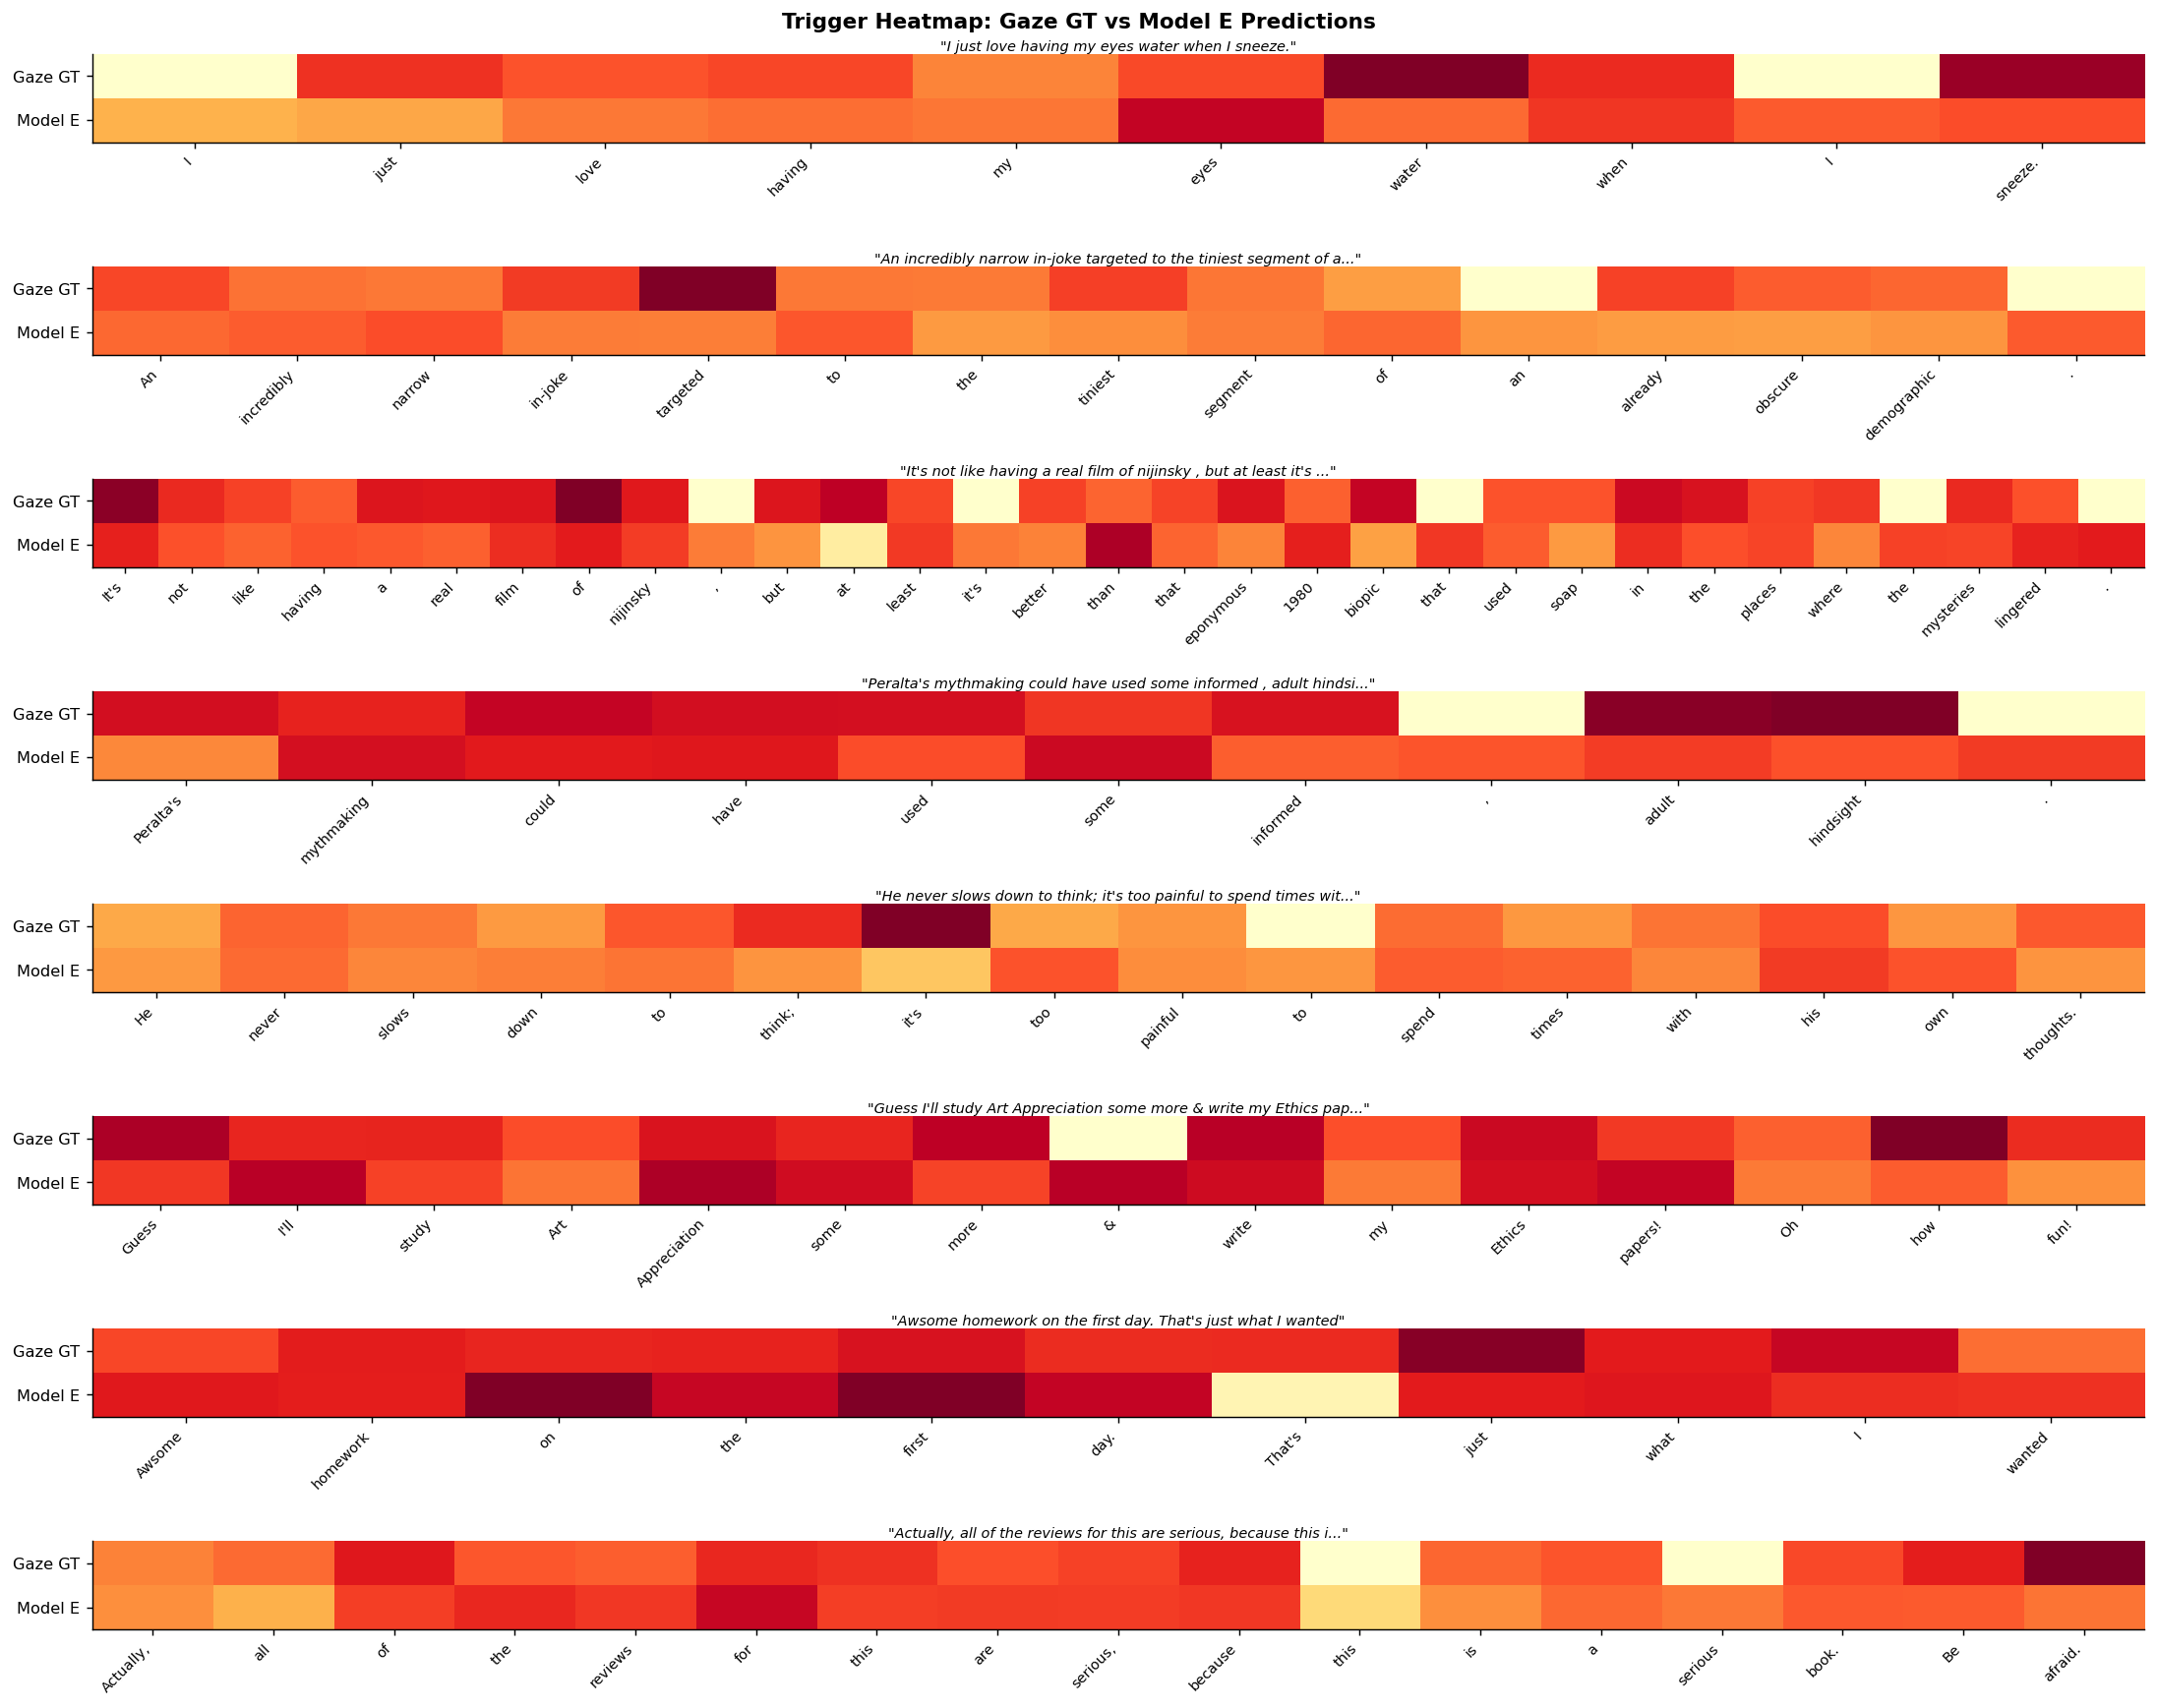

All figures saved to outputs/


In [16]:
plt.rcParams.update({'figure.dpi':130,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False})

COLORS = {
    'A_CE_only':'#95A5A6','B_Gaze_weakLam':'#AED6F1','C_Gaze_bestLam':'#2980B9',
    'D_Full_weakLam':'#F9E79F','E_Full_bestLam':'#27AE60','F_Full_strongLam':'#E74C3C'
}
SHORT = {
    'A_CE_only':'A\nCE-only',  'B_Gaze_weakLam':'B\nGaze\nλ=0.05',
    'C_Gaze_bestLam':f'C\nGaze\nλ=best', 'D_Full_weakLam':'D\nFull\nλ=0.05',
    'E_Full_bestLam':'E\nFull\nλ=best',  'F_Full_strongLam':'F\nFull\nλ=0.30'
}

# ── Figure 1: Training curves ─────────────────────────────────────────────────
main_models = ['A_CE_only','C_Gaze_bestLam','E_Full_bestLam']
fig, axes   = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Training Curves — Key Ablation Models', fontsize=13, fontweight='bold')

for mk in main_models:
    hist = all_histories[mk]
    ep   = range(1, len(hist['val_f1'])+1)
    lbl  = SHORT[mk].replace('\n',' ')
    axes[0].plot(ep, hist['val_f1'],   '-o', color=COLORS[mk], lw=2, label=lbl)
    axes[1].plot(ep, hist['pak'],      '-s', color=COLORS[mk], lw=2, label=lbl)
    axes[2].plot(ep, hist['entropy'],  '-D', color=COLORS[mk], lw=2, label=lbl)
    if 'kl_loss' in hist:
        axes[3].plot(ep, hist['kl_loss'], '--^', color=COLORS[mk], lw=2, label=lbl)

for ax, title, ylabel in zip(
    axes,
    ['Val Macro-F1', f'Val P@{CONFIG["topk"]}', 'Trigger Entropy', 'KL Loss'],
    ['F1', 'P@k', 'nats', 'KL']
):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel); ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/fig1_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Full ablation bar chart ─────────────────────────────────────────
# Compute test F1 for each model
test_cls = {}
for name, (m, _, _) in trained_models.items():
    m.eval(); tp, tl = [], []
    with torch.no_grad():
        for b in test_loader:
            ids  = b['input_ids'].to(DEVICE); mask = b['attention_mask'].to(DEVICE)
            cf   = b['contra_features'].to(DEVICE); labs = b['label'].to(DEVICE)
            sl, _ = m(ids, mask, cf)
            tp.extend(sl.argmax(-1).cpu().tolist())
            tl.extend(labs.cpu().tolist())
    test_cls[name] = f1_score(tl, tp, average='macro', zero_division=0)

ablation_names  = list(trained_models.keys())
all_names_w_base = ['Attn Baseline'] + ablation_names

metrics_to_plot = [
    ('f1',             'Test Macro-F1'),
    ('precision_at_k', f'Test P@{CONFIG["topk"]}'),
    ('spearman_rho',   'Spearman ρ'),
    ('token_overlap',  'Token IoU@k'),
    ('entropy',        'Trigger Entropy\n(lower=sharper)'),
    ('contra_hit_rate','Contra Hit Rate'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Full Ablation: All 6 Conditions — Test Set', fontsize=14, fontweight='bold')

for ax, (metric_key, title) in zip(axes.flat, metrics_to_plot):
    if metric_key == 'f1':
        vals = [0.0] + [test_cls[n] for n in ablation_names]
    else:
        vals = [test_trigger_results['Attn Baseline (no train)'].get(metric_key, 0)] + \
               [test_trigger_results[n].get(metric_key, 0) for n in ablation_names]

    colors = ['#BDC3C7'] + [COLORS[n] for n in ablation_names]
    short  = ['Attn\nBase'] + [SHORT[n] for n in ablation_names]
    bars   = ax.bar(range(len(vals)), vals, color=colors, edgecolor='white', lw=1.2, width=0.6)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(short, fontsize=8)
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)

    best_val = min(vals) if 'entropy' in metric_key else max(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')
        if v == best_val: bar.set_edgecolor('gold'); bar.set_linewidth(2.5)

plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/fig2_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Trigger heatmap ─────────────────────────────────────────────────
sarc_test8 = [r for r in test_rows if r['label']==1][:8]
model_E.eval()
fig, axes = plt.subplots(len(sarc_test8), 1, figsize=(17, len(sarc_test8)*1.7))
fig.suptitle('Trigger Heatmap: Gaze GT vs Model E Predictions',
             fontsize=12, fontweight='bold')

for ax, row in zip(axes, sarc_test8):
    words = row['gaze_words']; n = len(words)
    _, ga = align_to_tokens(row['text'], row['gaze_scores'], TOKENIZER, CONFIG['max_len'])
    toks, pred_p = get_trigger_probs(model_E, row, TOKENIZER, DEVICE)
    enc  = TOKENIZER(row['text'], truncation=True, padding='max_length',
                     max_length=CONFIG['max_len'], return_tensors='pt')
    wids = enc.word_ids(batch_index=0)
    wp   = np.zeros(n); wc = np.zeros(n)
    for ti, wid in enumerate(wids):
        if wid is not None and wid < n: wp[wid] += pred_p[ti]; wc[wid] += 1
    wp  = np.where(wc>0, wp/wc, 0); wp = wp/wp.sum() if wp.sum()>0 else wp
    data = np.stack([row['gaze_scores'][:n], wp], axis=0)
    ax.imshow(data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=data.max()+1e-8)
    ax.set_xticks(range(n)); ax.set_xticklabels(words, rotation=45, ha='right', fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Gaze GT', 'Model E'], fontsize=9)
    title = row['text'][:65] + '...' if len(row['text'])>65 else row['text']
    ax.set_title(f'"{title}"', fontsize=8, style='italic', pad=2)

plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('All figures saved to outputs/')